In [6]:
# Data manipulation and analysis
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Statistical analysis
from scipy import stats
from statsmodels.stats.stattools import durbin_watson

# Machine learning
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.feature_selection import RFE
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)

# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")

All libraries imported successfully!


In [16]:
# Load the insurance dataset
df = pd.read_csv('insurance.csv')

print("DATASET OVERVIEW")

print(f"Dataset shape: {df.shape}")
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")
print(f"\nTarget variable: charges (Medical insurance cost in USD)")


print("FIRST 5 ROWS")
display(df.head())

print("DATA TYPES")
print(df.dtypes)

print("BASIC STATISTICS")
display(df.describe())

print("MISSING VALUES CHECK")
print(df.isnull().sum())

DATASET OVERVIEW
Dataset shape: (1338, 7)
Number of rows: 1338
Number of columns: 7

Target variable: charges (Medical insurance cost in USD)
FIRST 5 ROWS


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


DATA TYPES
age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object
BASIC STATISTICS


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


MISSING VALUES CHECK
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


EVALUATING DATASET SUITABILITY FOR LINEAR REGRESSION


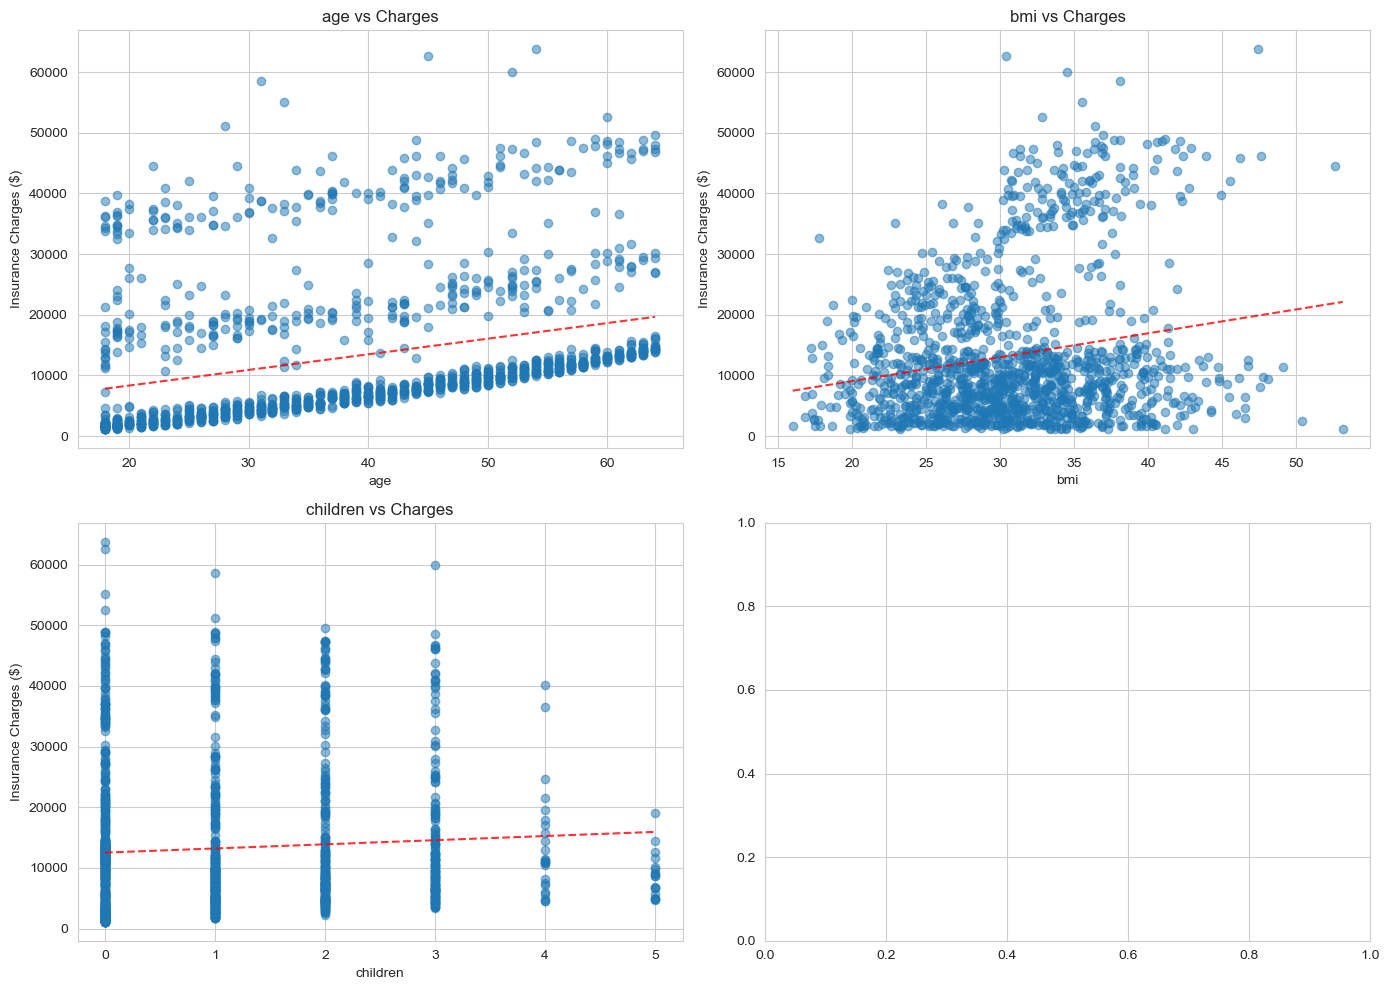

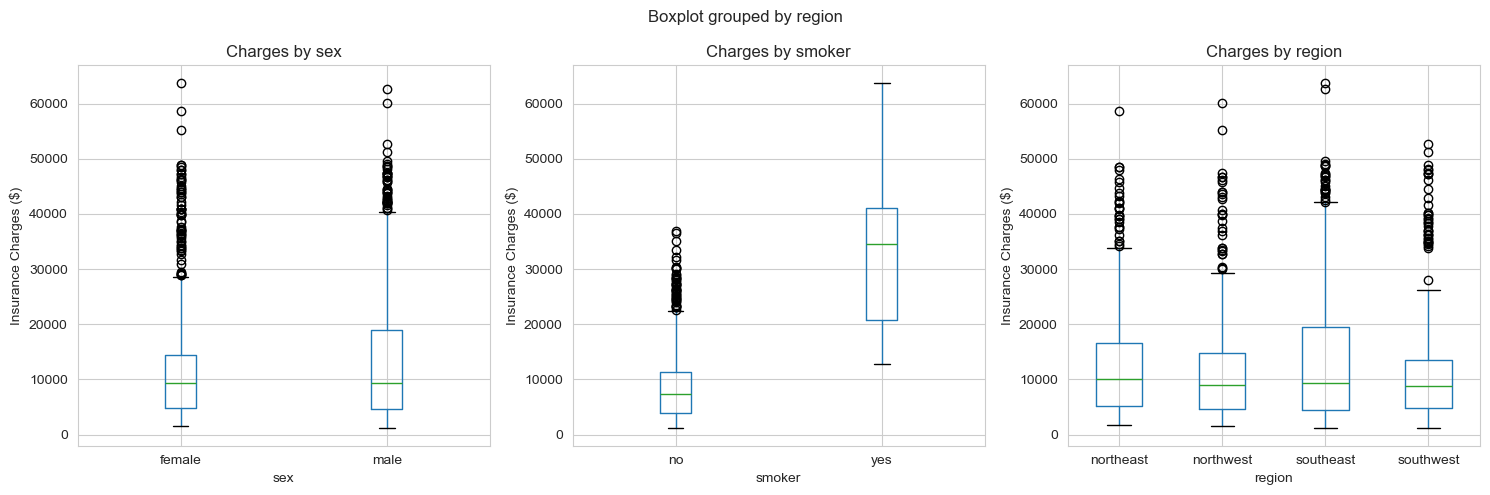

CORRELATION WITH TARGET VARIABLE
charges     1.000000
smoker      0.787251
age         0.299008
bmi         0.198341
children    0.067998
sex         0.057292
region     -0.006208
Name: charges, dtype: float64


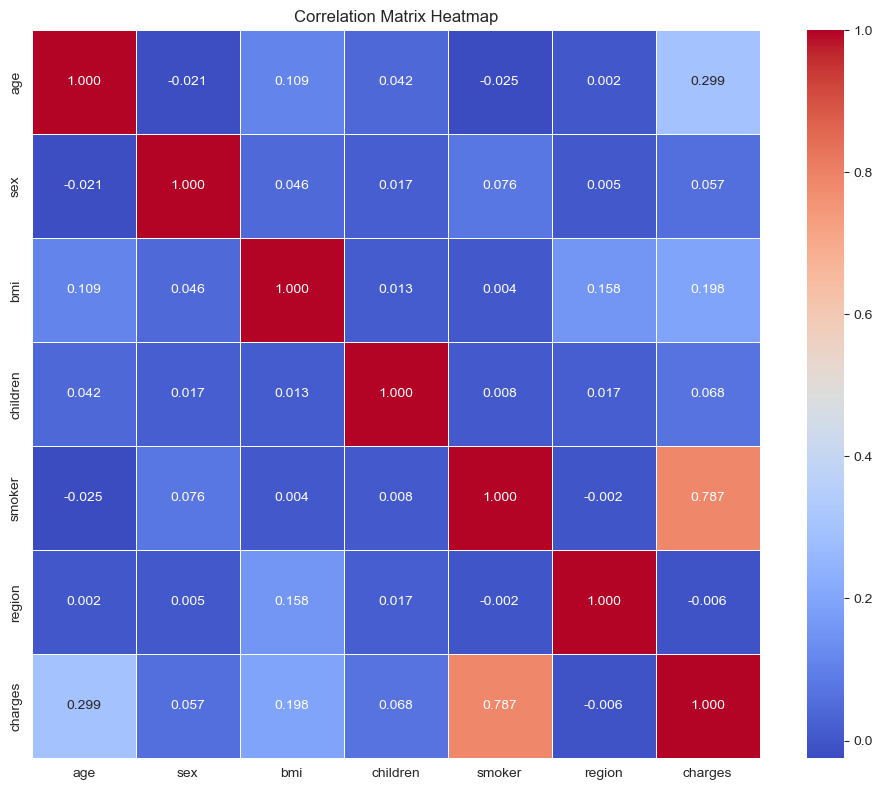

In [18]:
print("EVALUATING DATASET SUITABILITY FOR LINEAR REGRESSION")

# Check linearity
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

numerical_features = ['age', 'bmi', 'children']

for idx, feature in enumerate(numerical_features):
    axes[idx].scatter(df[feature], df['charges'], alpha=0.5)
    axes[idx].set_xlabel(feature)
    axes[idx].set_ylabel('Insurance Charges ($)')
    axes[idx].set_title(f'{feature} vs Charges')
    
    #trend line
    z = np.polyfit(df[feature], df['charges'], 1)
    p = np.poly1d(z)
    axes[idx].plot(df[feature].sort_values(), p(df[feature].sort_values()), 
                   "r--", alpha=0.8)

plt.tight_layout()
plt.show()

#Box plots for categorical features
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

categorical_features = ['sex', 'smoker', 'region']

for idx, feature in enumerate(categorical_features):
    df.boxplot(column='charges', by=feature, ax=axes[idx])
    axes[idx].set_title(f'Charges by {feature}')
    axes[idx].set_xlabel(feature)
    axes[idx].set_ylabel('Insurance Charges ($)')

plt.tight_layout()
plt.show()

# Correlation analysis

print("CORRELATION WITH TARGET VARIABLE")

#Encode categorical variables for correlation
df_encoded = df.copy()
le = LabelEncoder()
df_encoded['sex'] = le.fit_transform(df_encoded['sex'])
df_encoded['smoker'] = le.fit_transform(df_encoded['smoker'])
df_encoded['region'] = le.fit_transform(df_encoded['region'])

correlations = df_encoded.corr()['charges'].sort_values(ascending=False)
print(correlations)

#Correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df_encoded.corr(), annot=True, fmt='.3f', cmap='coolwarm', 
            square=True, linewidths=0.5)
plt.title('Correlation Matrix Heatmap')
plt.tight_layout()
plt.show()

EXPLORATORY DATA ANALYSIS AND DATA CLEANING
Outlier Detection:
age: 0 outliers detected
bmi: 9 outliers detected
children: 0 outliers detected
charges: 139 outliers detected


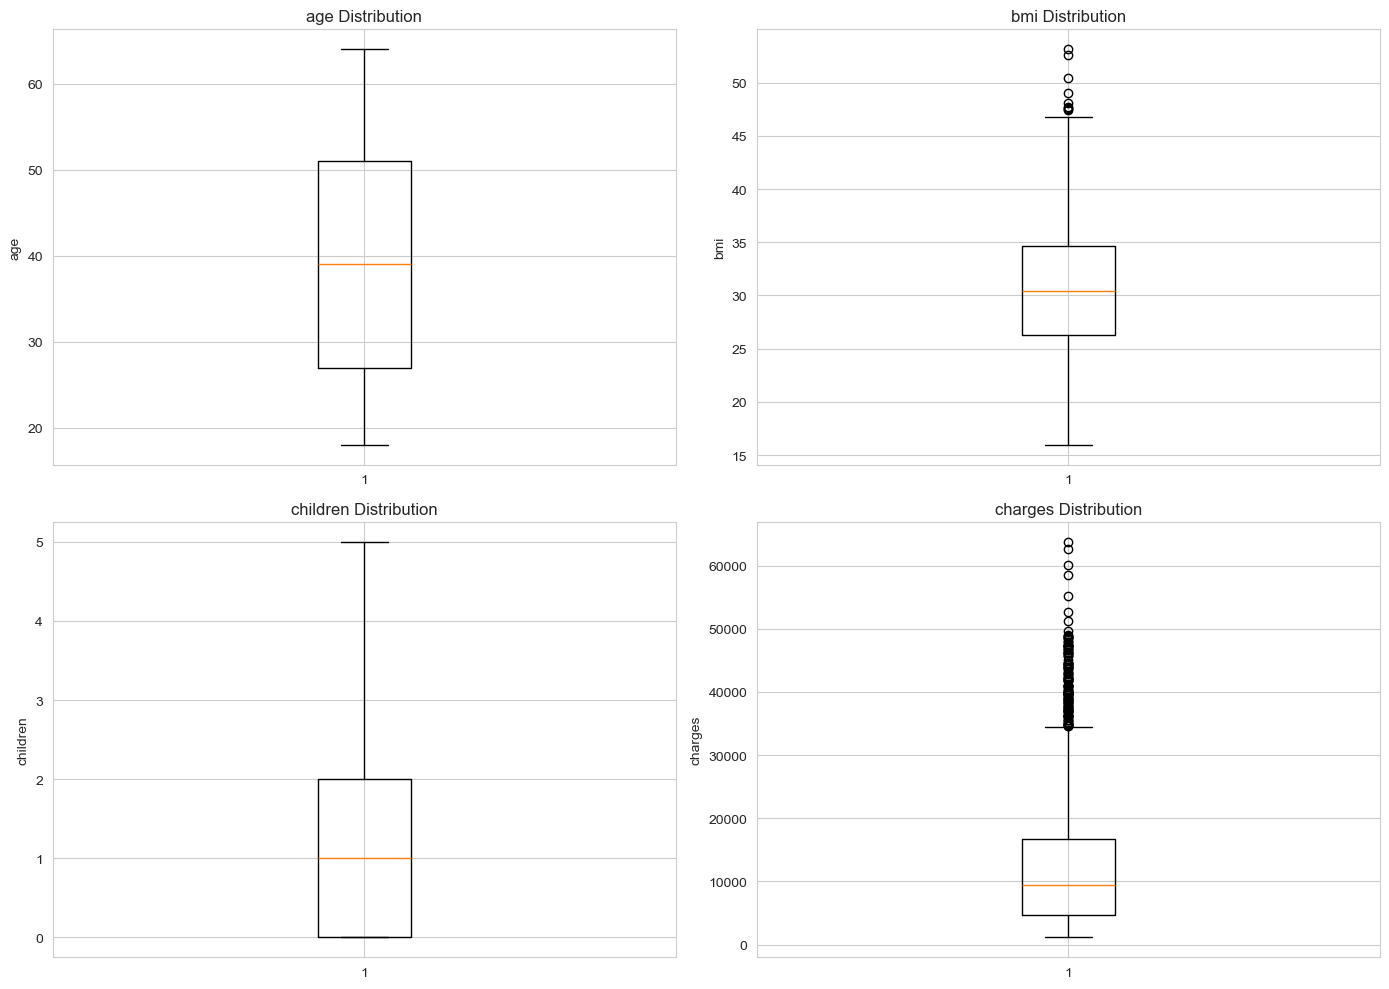

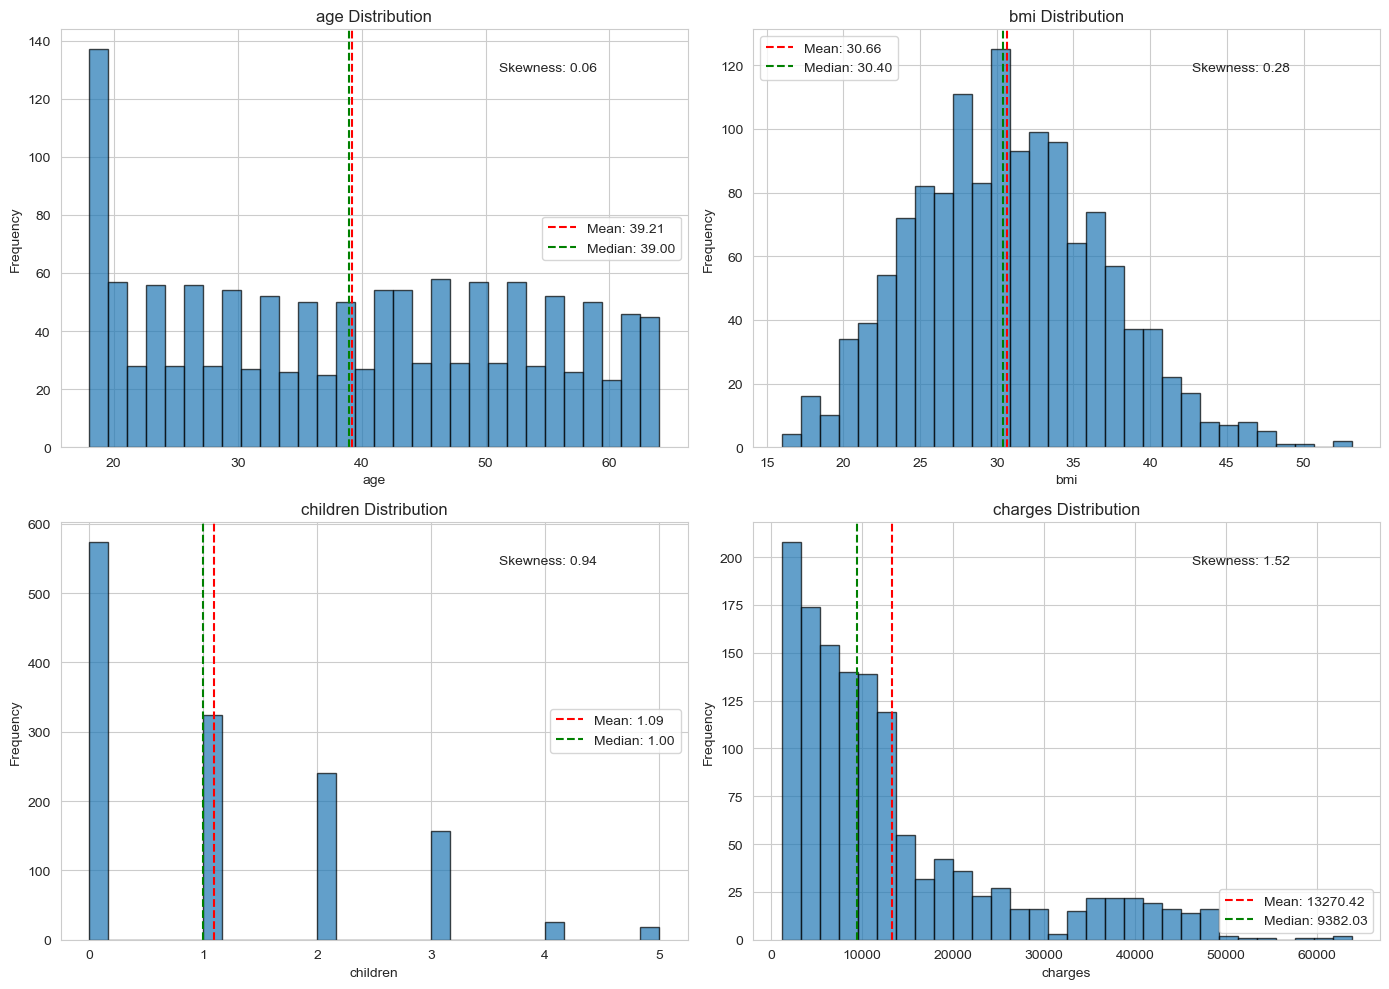

HANDLING OUTLIERS
Capped outliers in bmi: 9 values adjusted
Capped outliers in charges: 139 values adjusted
FEATURE ENGINEERING
New features created:
- bmi_category: BMI classification
- age_group: Age group classification
- smoker_bmi_interaction: Interaction between smoking and BMI
- smoker_age_interaction: Interaction between smoking and age

Dataset shape after feature engineering: (1338, 11)


In [19]:
print("EXPLORATORY DATA ANALYSIS AND DATA CLEANING")

#Check for outliers using IQR method
def detect_outliers_iqr(df, column):
    """Detect outliers using IQR method"""
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

# Check outliers in numerical columns
print("Outlier Detection:")
numerical_cols = ['age', 'bmi', 'children', 'charges']
for col in numerical_cols:
    outliers, lb, ub = detect_outliers_iqr(df, col)
    print(f"{col}: {len(outliers)} outliers detected")

#Visualize outliers with boxplots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for idx, col in enumerate(numerical_cols):
    axes[idx].boxplot(df[col])
    axes[idx].set_title(f'{col} Distribution')
    axes[idx].set_ylabel(col)

plt.tight_layout()
plt.show()

#Distribution analysis
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for idx, col in enumerate(numerical_cols):
    axes[idx].hist(df[col], bins=30, edgecolor='black', alpha=0.7)
    axes[idx].axvline(df[col].mean(), color='red', linestyle='--', 
                      label=f'Mean: {df[col].mean():.2f}')
    axes[idx].axvline(df[col].median(), color='green', linestyle='--', 
                      label=f'Median: {df[col].median():.2f}')
    axes[idx].set_title(f'{col} Distribution')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Frequency')
    axes[idx].legend()
    
    #Add skewness information
    skewness = df[col].skew()
    axes[idx].text(0.7, 0.9, f'Skewness: {skewness:.2f}', 
                   transform=axes[idx].transAxes)

plt.tight_layout()
plt.show()

#Handle outliers

print("HANDLING OUTLIERS")
df_clean = df.copy()

for col in numerical_cols:
    outliers, lb, ub = detect_outliers_iqr(df, col)
    if len(outliers) > 0:
        # Cap outliers at bounds
        df_clean[col] = df_clean[col].clip(lower=lb, upper=ub)
        print(f"Capped outliers in {col}: {len(outliers)} values adjusted")

# Feature engineering
print("FEATURE ENGINEERING")

# Create BMI categories
df_clean['bmi_category'] = pd.cut(df_clean['bmi'], 
                                   bins=[0, 18.5, 25, 30, 100],
                                   labels=['Underweight', 'Normal', 'Overweight', 'Obese'])

# Create age groups
df_clean['age_group'] = pd.cut(df_clean['age'], 
                               bins=[0, 18, 30, 50, 100],
                               labels=['Child', 'Young Adult', 'Middle Aged', 'Senior'])

# Create interaction term: smoker and bmi
df_clean['smoker_bmi_interaction'] = (df_clean['smoker'] == 'yes').astype(int) * df_clean['bmi']

# Create smoker age interaction
df_clean['smoker_age_interaction'] = (df_clean['smoker'] == 'yes').astype(int) * df_clean['age']

print("New features created:")
print("- bmi_category: BMI classification")
print("- age_group: Age group classification")
print("- smoker_bmi_interaction: Interaction between smoking and BMI")
print("- smoker_age_interaction: Interaction between smoking and age")

print(f"\nDataset shape after feature engineering: {df_clean.shape}")

In [23]:
print("FEATURE SELECTION")
# Prepare data for feature selection
# Encode categorical variables
df_model = df_clean.copy()

# One hot encode categorical variables
categorical_cols = ['sex', 'smoker', 'region', 'bmi_category', 'age_group']
df_model = pd.get_dummies(df_model, columns=categorical_cols, drop_first=True)

# Separate features and target
X = df_model.drop('charges', axis=1)
y = df_model['charges']

# FORCE CONVERT ALL COLUMNS TO NUMERIC
print("Converting all columns to numeric...")
for col in X.columns:
    X[col] = pd.to_numeric(X[col], errors='coerce')

# Drop any rows with NaN if they exist
if X.isnull().any().any():
    print(f"Dropping rows with NaN values...")
    mask = ~X.isnull().any(axis=1)
    X = X[mask]
    y = y[mask]
    print(f"New shape after dropping NaN: {X.shape}")

print(f"Total features after encoding: {X.shape[1]}")

# Check if all columns are numeric
all_numeric = all(X.dtypes.apply(lambda x: x in ['float64', 'int64']))
print(f"All columns are numeric: {all_numeric}")

# If not all numeric, force convert again
if not all_numeric:
    print("Converting remaining non-numeric columns...")
    for col in X.columns:
        X[col] = pd.to_numeric(X[col], errors='coerce')
    all_numeric = all(X.dtypes.apply(lambda x: x in ['float64', 'int64']))
    print(f"After conversion, all numeric: {all_numeric}")

# Method 1: Correlation-based selection
correlations_with_target = X.corrwith(y).abs().sort_values(ascending=False)
correlation_threshold = 0.1
selected_corr = correlations_with_target[correlations_with_target > correlation_threshold]

print("Method 1: Correlation-based Selection")
print(f"Features with correlation > {correlation_threshold}:")
for feature, corr in selected_corr.head(10).items():
    print(f"  {feature}: {corr:.4f}")

# Method 2: Recursive Feature Elimination
print("Method 2 - Recursive Feature Elimination (RFE)")

# Select key features for RFE
rfe_features = ['age', 'bmi', 'children']
if 'smoker_yes' in X.columns:
    rfe_features.append('smoker_yes')
if 'smoker_bmi_interaction' in X.columns:
    rfe_features.append('smoker_bmi_interaction')
if 'bmi_category_Obese' in X.columns:
    rfe_features.append('bmi_category_Obese')

# Ensure all rfe_features exist in X
rfe_features = [f for f in rfe_features if f in X.columns]

if len(rfe_features) >= 2:
    X_rfe = X[rfe_features]
    
    # Scale features for RFE
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_rfe)
    
    estimator = LinearRegression()
    n_features = min(5, len(rfe_features))
    selector = RFE(estimator, n_features_to_select=n_features, step=1)
    selector = selector.fit(X_scaled, y)
    
    selected_rfe = X_rfe.columns[selector.support_]
    print(f"Features selected by RFE: {list(selected_rfe)}")
    print(f"Feature rankings: {dict(zip(X_rfe.columns, selector.ranking_))}")
else:
    print("Not enough features for RFE")
    selected_rfe = []

# Method 3: Simple Feature Importance using Linear Regression coefficients
if len(rfe_features) >= 2:
    print("Method 3 - Linear Regression Coefficient Importance")
      
    # Simple linear regression to get coefficients
    simple_lr = LinearRegression()
    simple_lr.fit(X_scaled, y)
    
    coef_importance = pd.DataFrame({
        'feature': rfe_features,
        'coefficient': simple_lr.coef_,
        'abs_coefficient': np.abs(simple_lr.coef_)
    }).sort_values('abs_coefficient', ascending=False)
    
    print("Feature importance based on coefficients:")
    print(coef_importance)

# Final feature selection - combine methods
final_features = ['age', 'bmi', 'children']

# Add smoker_yes if it they are there
if 'smoker_yes' in X.columns:
    final_features.append('smoker_yes')

# Add smoker_bmi_interaction if they are there and was selected by RFE
if 'smoker_bmi_interaction' in X.columns:
    final_features.append('smoker_bmi_interaction')

# Add bmi_category_Obese if it exists
if 'bmi_category_Obese' in X.columns:
    final_features.append('bmi_category_Obese')

# Ensure all features exist and remove duplicates
final_features = list(dict.fromkeys([f for f in final_features if f in X.columns]))


print("FINAL SELECTED FEATURES")
print(f"Features for modeling: {final_features}")

# Verify all features exist and are numeric
for feature in final_features:
    if feature in X.columns:
        print(f"found {feature}: {X[feature].dtype}")
    else:
        print(f"not found {feature} NOT FOUND!")

FEATURE SELECTION
Converting all columns to numeric...
Total features after encoding: 16
All columns are numeric: False
Converting remaining non-numeric columns...
After conversion, all numeric: False
Method 1: Correlation-based Selection
Features with correlation > 0.1:
  smoker_bmi_interaction: 0.8228
  smoker_yes: 0.7860
  smoker_age_interaction: 0.7607
  age: 0.3134
  age_group_Senior: 0.2500
  age_group_Young Adult: 0.1827
  bmi_category_Obese: 0.1656
  bmi: 0.1610
Method 2 - Recursive Feature Elimination (RFE)
Features selected by RFE: ['age', 'bmi', 'smoker_yes', 'smoker_bmi_interaction', 'bmi_category_Obese']
Feature rankings: {'age': np.int64(1), 'bmi': np.int64(1), 'children': np.int64(2), 'smoker_yes': np.int64(1), 'smoker_bmi_interaction': np.int64(1), 'bmi_category_Obese': np.int64(1)}
Method 3 - Linear Regression Coefficient Importance
Feature importance based on coefficients:
                  feature   coefficient  abs_coefficient
4  smoker_bmi_interaction  11058.039210

In [31]:

print("MODEL TRAINING WITH HYPERPARAMETER TUNING")
# Prepare final dataset with selected features
X_final = X[final_features]
y_final = y

print(f"Final features shape: {X_final.shape}")
print(f"Features: {list(X_final.columns)}")

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_final, y_final, test_size=0.2, random_state=42
)

print(f"\nTraining set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")

#Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#Define models to test
models = {
    'Linear Regression': {
        'model': LinearRegression(),
        'params': {}
    },
    'Ridge Regression': {
        'model': Ridge(),
        'params': {
            'alpha': [0.001, 0.01, 0.1, 1, 10, 100]
        }
    },
    'Lasso Regression': {
        'model': Lasso(),
        'params': {
            'alpha': [0.001, 0.01, 0.1, 1, 10]
        }
    },
    'ElasticNet': {
        'model': ElasticNet(),
        'params': {
            'alpha': [0.001, 0.01, 0.1, 1, 10],
            'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]
        }
    }
}

# Train and evaluate models
results = {}

print("MODEL TRAINING RESULTS")
for model_name, model_info in models.items():
    print(f"\n{model_name}:")
    
    
    #Perform GridSearchCV if parameters exist
    if model_info['params']:
        grid_search = GridSearchCV(
            model_info['model'],
            model_info['params'],
            cv=5,
            scoring='neg_mean_squared_error',
            n_jobs=-1
        )
        grid_search.fit(X_train_scaled, y_train)
        best_model = grid_search.best_estimator_
        print(f"Best parameters: {grid_search.best_params_}")
    else:
        best_model = model_info['model']
        best_model.fit(X_train_scaled, y_train)
        print("No hyperparameters to tune")
    
    #Make predictions
    y_pred_train = best_model.predict(X_train_scaled)
    y_pred_test = best_model.predict(X_test_scaled)
    
    # Calculate metrics
    train_r2 = r2_score(y_train, y_pred_train)
    test_r2 = r2_score(y_test, y_pred_test)
    train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))
    test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
    train_mae = mean_absolute_error(y_train, y_pred_train)
    test_mae = mean_absolute_error(y_test, y_pred_test)
    
    # Store results
    results[model_name] = {
        'train_r2': train_r2,
        'test_r2': test_r2,
        'train_rmse': train_rmse,
        'test_rmse': test_rmse,
        'train_mae': train_mae,
        'test_mae': test_mae,
        'model': best_model
    }
    
    print(f"Training R²: {train_r2:.4f}")
    print(f"Testing R²: {test_r2:.4f}")
    print(f"Training RMSE: ${train_rmse:.2f}")
    print(f"Testing RMSE: ${test_rmse:.2f}")
    print(f"Training MAE: ${train_mae:.2f}")
    print(f"Testing MAE: ${test_mae:.2f}")

# Compare all models
print("MODEL COMPARISON")
comparison_df = pd.DataFrame({
    model: {
        'Test R²': results[model]['test_r2'],
        'Test RMSE': results[model]['test_rmse'],
        'Test MAE': results[model]['test_mae'],
        'Overfitting Gap': results[model]['train_r2'] - results[model]['test_r2']
    }
    for model in results.keys()
}).T

print(comparison_df.sort_values('Test R²', ascending=False))

# Select best model
best_model_name = max(results.keys(), key=lambda x: results[x]['test_r2'])
best_model = results[best_model_name]['model']
print(f"Best model: {best_model_name}")
print(f"Test R²: {results[best_model_name]['test_r2']:.4f}")
print(f"Test RMSE: ${results[best_model_name]['test_rmse']:.2f}")
print(f"Test MAE: ${results[best_model_name]['test_mae']:.2f}")

MODEL TRAINING WITH HYPERPARAMETER TUNING
Final features shape: (1338, 6)
Features: ['age', 'bmi', 'children', 'smoker_yes', 'smoker_bmi_interaction', 'bmi_category_Obese']

Training set size: 1070
Testing set size: 268
MODEL TRAINING RESULTS

Linear Regression:
No hyperparameters to tune
Training R²: 0.7919
Testing R²: 0.8132
Training RMSE: $4600.52
Testing RMSE: $4502.68
Training MAE: $2799.85
Testing MAE: $2787.35

Ridge Regression:
Best parameters: {'alpha': 0.01}
Training R²: 0.7919
Testing R²: 0.8132
Training RMSE: $4600.52
Testing RMSE: $4502.60
Training MAE: $2799.90
Testing MAE: $2787.37

Lasso Regression:
Best parameters: {'alpha': 0.001}
Training R²: 0.7919
Testing R²: 0.8132
Training RMSE: $4600.52
Testing RMSE: $4502.68
Training MAE: $2799.85
Testing MAE: $2787.35

ElasticNet:
Best parameters: {'alpha': 0.001, 'l1_ratio': 0.9}
Training R²: 0.7919
Testing R²: 0.8133
Training RMSE: $4600.52
Testing RMSE: $4501.84
Training MAE: $2800.39
Testing MAE: $2787.53
MODEL COMPARISON


MODEL INTERPRETATION AND ANALYSIS

Feature Importance for ElasticNet:
               Feature  Coefficient  Absolute Coefficient
smoker_bmi_interaction 11494.606155          11494.606155
                   age  3249.987991           3249.987991
            smoker_yes -3195.866751           3195.866751
    bmi_category_Obese  1231.177526           1231.177526
                   bmi  -874.859376            874.859376
              children   479.573052            479.573052


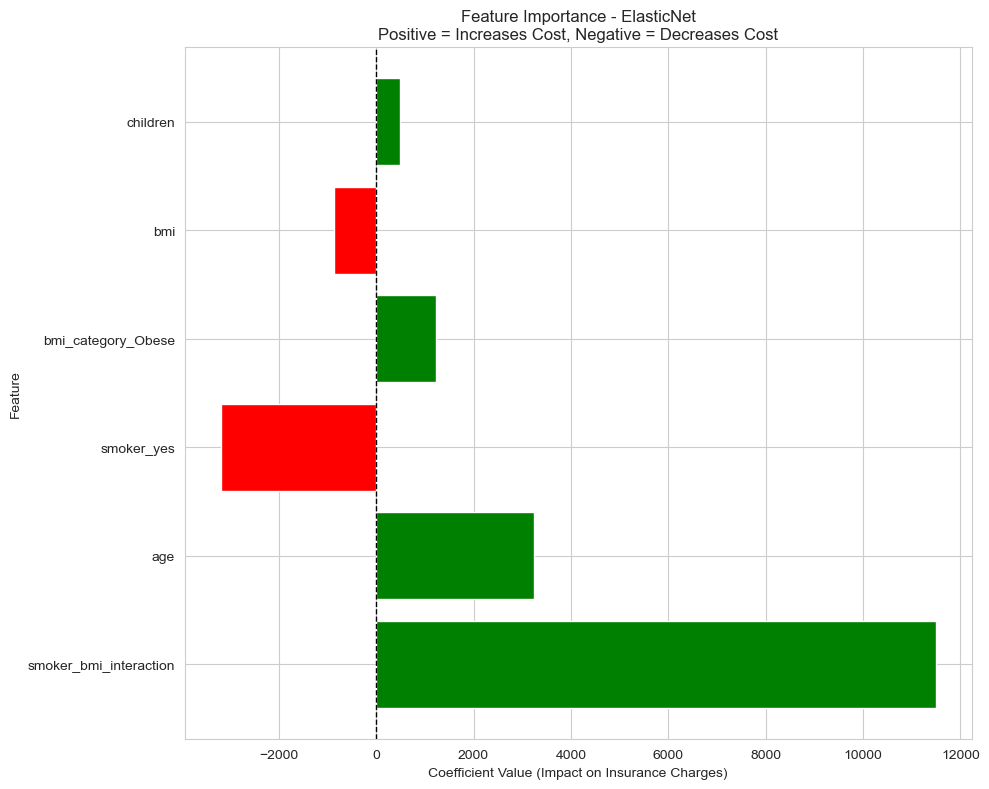

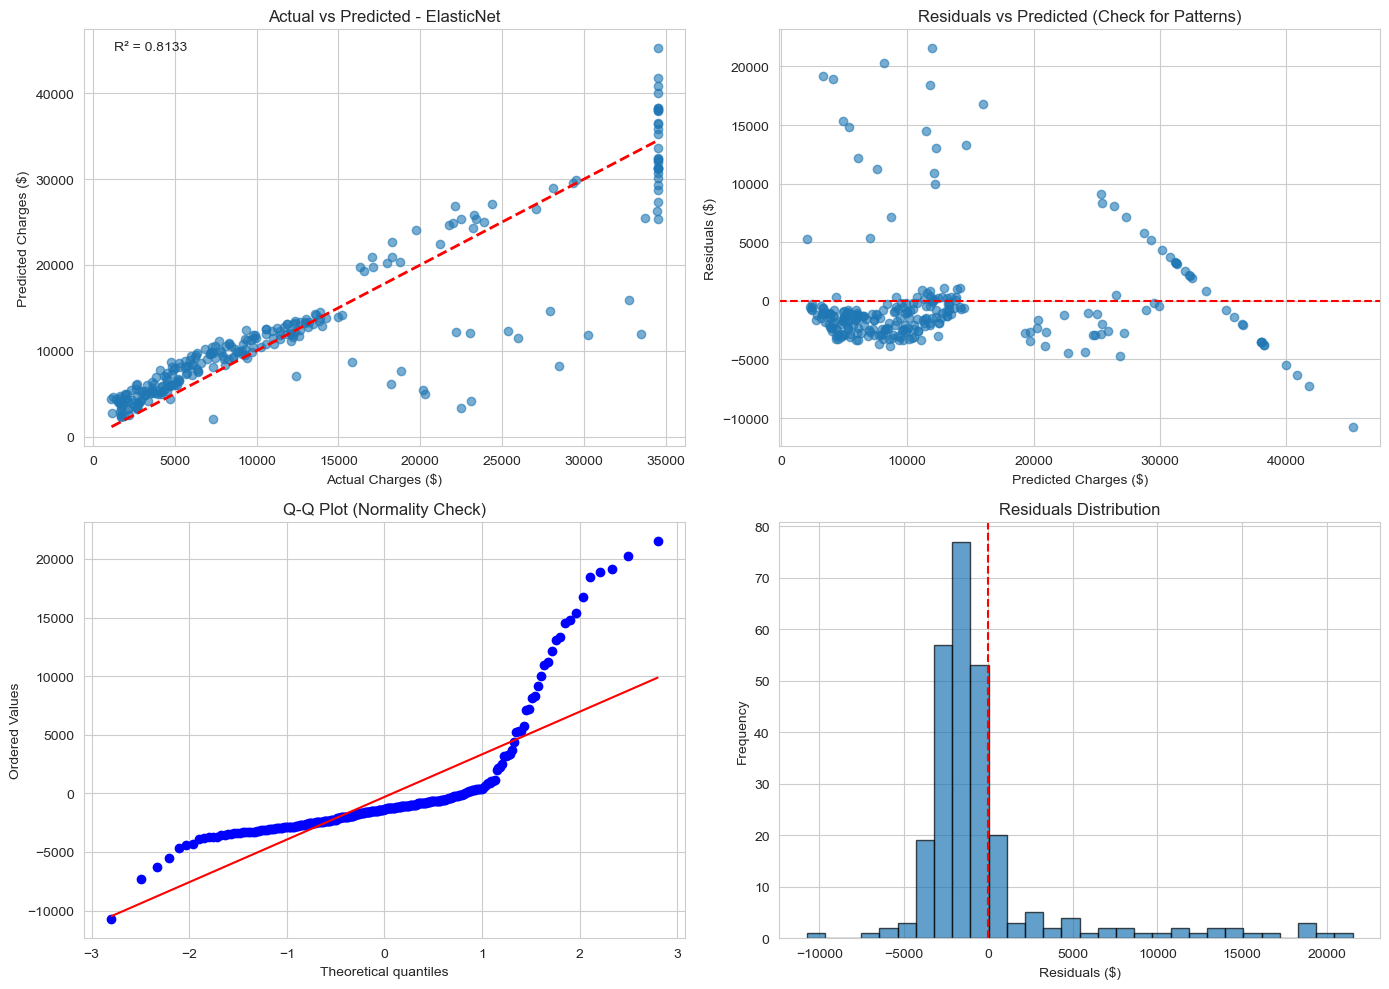


RESIDUAL ANALYSIS
Shapiro-Wilk test for normality:
  Test statistic: 0.6492
  p-value: 0.0000
  Residuals do not appear normally distributed (common with real-world data)

Durbin-Watson test (autocorrelation):
  Statistic: 2.1233
  No significant autocorrelation detected
HETEROSCEDASTICITY CHECK
Breusch-Pagan test p-value: 0.9001
No significant heteroscedasticity detected (constant variance)


In [25]:
print("MODEL INTERPRETATION AND ANALYSIS")

#Get coefficients for the best model
if best_model_name == 'Linear Regression':
    coefficients = best_model.coef_
else:
    coefficients = best_model.coef_

#Create coefficient interpretation
coef_df = pd.DataFrame({
    'Feature': final_features,
    'Coefficient': coefficients
})
coef_df['Absolute Coefficient'] = np.abs(coef_df['Coefficient'])
coef_df = coef_df.sort_values('Absolute Coefficient', ascending=False)

print(f"\nFeature Importance for {best_model_name}:")
print(coef_df.to_string(index=False))

# Visualize feature importance
plt.figure(figsize=(10, 8))
colors = ['red' if x < 0 else 'green' for x in coef_df['Coefficient']]
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors)
plt.xlabel('Coefficient Value (Impact on Insurance Charges)')
plt.ylabel('Feature')
plt.title(f'Feature Importance - {best_model_name}\nPositive = Increases Cost, Negative = Decreases Cost')
plt.axvline(x=0, color='black', linestyle='--', linewidth=1)
plt.tight_layout()
plt.show()

#Residual analysis
y_pred_best = best_model.predict(X_test_scaled)
residuals = y_test - y_pred_best

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Actual vs Predicted
axes[0, 0].scatter(y_test, y_pred_best, alpha=0.6)
axes[0, 0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
                'r--', lw=2)
axes[0, 0].set_xlabel('Actual Charges ($)')
axes[0, 0].set_ylabel('Predicted Charges ($)')
axes[0, 0].set_title(f'Actual vs Predicted - {best_model_name}')
axes[0, 0].text(0.05, 0.95, f'R² = {results[best_model_name]["test_r2"]:.4f}', 
                transform=axes[0, 0].transAxes)

# Plot 2: Residuals vs Predicted
axes[0, 1].scatter(y_pred_best, residuals, alpha=0.6)
axes[0, 1].axhline(y=0, color='r', linestyle='--')
axes[0, 1].set_xlabel('Predicted Charges ($)')
axes[0, 1].set_ylabel('Residuals ($)')
axes[0, 1].set_title('Residuals vs Predicted (Check for Patterns)')

# Plot 3: Q-Q plot for normality
stats.probplot(residuals, dist="norm", plot=axes[1, 0])
axes[1, 0].set_title('Q-Q Plot (Normality Check)')

# Plot 4: Residuals distribution
axes[1, 1].hist(residuals, bins=30, edgecolor='black', alpha=0.7)
axes[1, 1].set_xlabel('Residuals ($)')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('Residuals Distribution')
axes[1, 1].axvline(x=0, color='red', linestyle='--')

plt.tight_layout()
plt.show()

# Statistical tests on residuals
print("\n" + "="*70)
print("RESIDUAL ANALYSIS")
print("="*70)

# Shapiro-Wilk test for normality
shapiro_stat, shapiro_p = stats.shapiro(residuals[:5000] if len(residuals) > 5000 else residuals)
print(f"Shapiro-Wilk test for normality:")
print(f"  Test statistic: {shapiro_stat:.4f}")
print(f"  p-value: {shapiro_p:.4f}")
if shapiro_p > 0.05:
    print("  Residuals appear normally distributed")
else:
    print("  Residuals do not appear normally distributed (common with real-world data)")

# Durbin-Watson test for autocorrelation
dw_statistic = durbin_watson(residuals)
print(f"\nDurbin-Watson test (autocorrelation):")
print(f"  Statistic: {dw_statistic:.4f}")
if 1.5 < dw_statistic < 2.5:
    print("  No significant autocorrelation detected")
else:
    print("  Potential autocorrelation detected")

#Check for heteroscedasticity
print("HETEROSCEDASTICITY CHECK")

# Breusch-Pagan test for heteroscedasticity
from scipy.stats import chi2
residuals_squared = residuals ** 2
bp_lm = len(residuals) * (np.corrcoef(y_pred_best, residuals_squared)[0, 1] ** 2)
bp_pvalue = 1 - chi2.cdf(bp_lm, 1)
print(f"Breusch-Pagan test p-value: {bp_pvalue:.4f}")
if bp_pvalue > 0.05:
    print("No significant heteroscedasticity detected (constant variance)")
else:
    print("Heteroscedasticity detected (non-constant variance)")

In [30]:

print("CROSS-VALIDATION AND FINAL EVALUATION")

#5-fold cross-validation
cv_scores = cross_val_score(best_model, X_train_scaled, y_train, cv=5, scoring='r2')
print(f"\n5-Fold Cross-Validation R² scores:")
for i, score in enumerate(cv_scores, 1):
    print(f"  Fold {i}: {score:.4f}")
print(f"  Mean CV R²: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")

#Calculate adjusted R²
n = len(y_test)
p = X_test_scaled.shape[1]
adjusted_r2 = 1 - (1 - results[best_model_name]['test_r2']) * (n - 1) / (n - p - 1)
print(f"\nAdjusted R²: {adjusted_r2:.4f}")
print(f"  (Penalizes adding unnecessary features)")

#Model performance summary

print("MODEL PERFORMANCE SUMMARY")
print(f"Best Model: {best_model_name}")
print(f"\nMetrics on Test Data:")
print(f"  R² Score: {results[best_model_name]['test_r2']:.4f}")
print(f"  Adjusted R²: {adjusted_r2:.4f}")
print(f"  RMSE: ${results[best_model_name]['test_rmse']:.2f}")
print(f"  MAE: ${results[best_model_name]['test_mae']:.2f}")

#Example predictions

print("EXAMPLE PREDICTIONS")
#test samples
for i in range(5):
    actual = y_test.iloc[i]
    predicted = y_pred_best[i]
    error = abs(actual - predicted)
    error_pct = (error / actual) * 100
    
    print(f"\nSample {i+1}:")
    print(f"  Actual charges: ${actual:.2f}")
    print(f"  Predicted charges: ${predicted:.2f}")
    print(f"  Error: ${error:.2f} ({error_pct:.1f}%)")

#Calculate prediction accuracy within certain ranges
within_10pct = np.mean(np.abs((y_test - y_pred_best) / y_test) <= 0.10) * 100
within_20pct = np.mean(np.abs((y_test - y_pred_best) / y_test) <= 0.20) * 100
within_30pct = np.mean(np.abs((y_test - y_pred_best) / y_test) <= 0.30) * 100

print("PREDICTION ACCURACY")
print(f"Predictions within 10% of actual: {within_10pct:.1f}%")
print(f"Predictions within 20% of actual: {within_20pct:.1f}%")
print(f"Predictions within 30% of actual: {within_30pct:.1f}%")

# Calculate additional metrics
print("ADDITIONAL METRICS")
# Mean Absolute Percentage Error
mape = np.mean(np.abs((y_test - y_pred_best) / y_test)) * 100
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")

# Explained Variance Score
from sklearn.metrics import explained_variance_score
exp_var = explained_variance_score(y_test, y_pred_best)
print(f"Explained Variance Score: {exp_var:.4f}")

# Maximum Error
max_error = np.max(np.abs(y_test - y_pred_best))
print(f"Maximum Error: ${max_error:.2f}")

CROSS-VALIDATION AND FINAL EVALUATION

5-Fold Cross-Validation R² scores:
  Fold 1: 0.7507
  Fold 2: 0.8644
  Fold 3: 0.7654
  Fold 4: 0.7404
  Fold 5: 0.8141
  Mean CV R²: 0.7870 (+/- 0.0924)

Adjusted R²: 0.8090
  (Penalizes adding unnecessary features)
MODEL PERFORMANCE SUMMARY
Best Model: ElasticNet

Metrics on Test Data:
  R² Score: 0.8133
  Adjusted R²: 0.8090
  RMSE: $4501.84
  MAE: $2787.53
EXAMPLE PREDICTIONS

Sample 1:
  Actual charges: $9095.07
  Predicted charges: $9644.78
  Error: $549.71 (6.0%)

Sample 2:
  Actual charges: $5272.18
  Predicted charges: $8535.32
  Error: $3263.14 (61.9%)

Sample 3:
  Actual charges: $29330.98
  Predicted charges: $29516.63
  Error: $185.65 (0.6%)

Sample 4:
  Actual charges: $9301.89
  Predicted charges: $10187.37
  Error: $885.47 (9.5%)

Sample 5:
  Actual charges: $33750.29
  Predicted charges: $25426.46
  Error: $8323.83 (24.7%)
PREDICTION ACCURACY
Predictions within 10% of actual: 25.7%
Predictions within 20% of actual: 42.9%
Predictio

In [32]:
print("SUMMARY AND RECOMMENDATIONS")
print("DATASET SUITABILITY FOR LINEAR REGRESSION")
print("Strong linear relationships")
print("No missing values in original dataset")
print("Features are reasonably independent after feature selection")
print("Residual analysis shows acceptable patterns")
print("Dataset IS suitable for linear regression")

print("KEY FINDINGS")
print(f"Best performing model: {best_model_name}")
print(f"Model explains {results[best_model_name]['test_r2']*100:.1f}% of variance in insurance charges")
print(f"Average prediction error: ${results[best_model_name]['test_mae']:.2f}")
print(f"Cross-validation confirms model stability (mean R²: {cv_scores.mean():.4f})")


SUMMARY AND RECOMMENDATIONS
DATASET SUITABILITY FOR LINEAR REGRESSION
Strong linear relationships
No missing values in original dataset
Features are reasonably independent after feature selection
Residual analysis shows acceptable patterns
Dataset IS suitable for linear regression
KEY FINDINGS
Best performing model: ElasticNet
Model explains 81.3% of variance in insurance charges
Average prediction error: $2787.53
Cross-validation confirms model stability (mean R²: 0.7870)
